# Notebook说明
这是一个消融实验，用于探究CerebriScan_former模型中卷积MoE模块是否有必要添加。
同时探究卷积MoE模块对系统能力的提升程度。

检测系统配置

In [1]:
import os
print('CPU可用核心数:',os.cpu_count())

CPU可用核心数: 52


In [2]:
#获取GPU可用性
import tensorflow as tf
print('GPU可用性:',tf.test.is_gpu_available())
print("可用GPU数: ", len(tf.config.experimental.list_physical_devices('GPU')))

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU可用性: True
可用GPU数:  2


2025-09-12 12:06:07.193386: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-12 12:06:09.154699: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:65:04.0, compute capability: 7.0
2025-09-12 12:06:09.155861: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:04.0, compute capability: 7.0


读取图像文件地址

In [3]:
#读取文件地址
import pandas as pd
ImageFile=pd.read_csv('/root/StrokeDataset/ImageFiles.csv')
ImageFile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   6650 non-null   int64 
 1   Iamge Path   6650 non-null   object
 2   Iamge Label  6650 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 156.0+ KB


In [4]:
#查看数据标签分布
import matplotlib.pyplot as plt
from collections import Counter
def EveluateLabel(labellist):
    print('样本标签统计:',Counter(labellist))
    hist=plt.figure(dpi=72)
    plt.hist(labellist)
    plt.show()

样本标签统计: Counter({0: 4427, 1: 1130, 2: 1093})


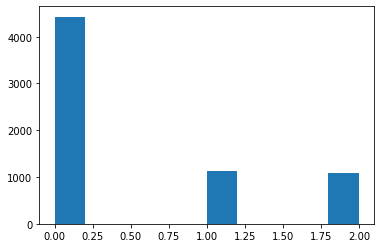

In [5]:
EveluateLabel(labellist=ImageFile.loc[:,'Iamge Label'])

构建数据输入流

In [6]:
#分割数据集+分层抽样
from sklearn.model_selection import train_test_split
TrainPath,SplitPath,TrainLabel,SplitLabel=train_test_split(ImageFile.loc[:,'Iamge Path'],ImageFile.loc[:,'Iamge Label'],train_size=0.7,
                                                           stratify=ImageFile.loc[:,'Iamge Label'],random_state=2025)
ValidPath,TestPath,ValidLabel,TestLabel=train_test_split(SplitPath,SplitLabel,train_size=0.5,stratify=SplitLabel,random_state=2025)
print('训练集地址:{0},验证集地址:{1},测试集地址:{2}'.format(len(TrainPath),len(ValidPath),len(TestPath)))
print('训练集标签:{0},验证集标签:{1},测试集标签:{2}'.format(len(TrainLabel),len(ValidLabel),len(TestLabel)))

训练集地址:4655,验证集地址:997,测试集地址:998
训练集标签:4655,验证集标签:997,测试集标签:998


样本标签统计: Counter({0: 3099, 1: 791, 2: 765})


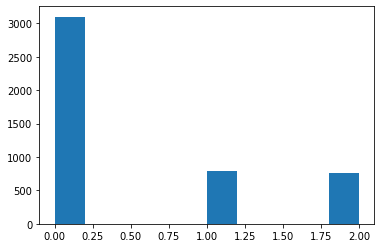

In [7]:
#训练集标签分布
EveluateLabel(labellist=TrainLabel)

样本标签统计: Counter({0: 664, 1: 169, 2: 164})


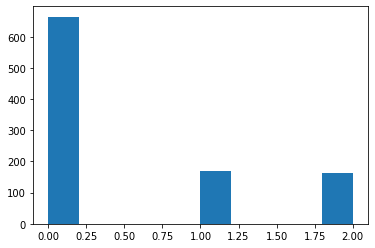

In [8]:
#验证集标签分布
EveluateLabel(labellist=ValidLabel)

样本标签统计: Counter({0: 664, 1: 170, 2: 164})


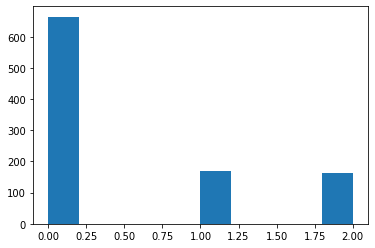

In [9]:
#测试集标签分布
EveluateLabel(labellist=TestLabel)

In [10]:
#编写数据读取函数
import tensorflow as tf
def ReadImageData(path,ImageLabel):
        image_io=tf.io.read_file(path)    #读取文件
        image_data=tf.image.decode_png(image_io,channels=3)    #解码图像数据
        image_datare=tf.image.resize(image_data,(512,512))
        image_normal=tf.cast(image_datare, tf.float32)/255.0
        return (image_normal,ImageLabel)

In [11]:
#使用文件路径方法批量读取数据
#训练集
FilePathDataset_Train=tf.data.Dataset.from_tensor_slices((TrainPath,TrainLabel)).repeat(2)    #文件路径数据集
ImageDataset_Train=FilePathDataset_Train.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Train=ImageDataset_Train.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#验证集
FilePathDataset_Valid=tf.data.Dataset.from_tensor_slices((ValidPath,ValidLabel)).repeat(2)    #文件路径数据集
ImageDataset_Valid=FilePathDataset_Valid.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Valid=ImageDataset_Valid.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)
#测试集
FilePathDataset_Test=tf.data.Dataset.from_tensor_slices((TestPath,TestLabel)).repeat(2)    #文件路径数据集
ImageDataset_Test=FilePathDataset_Test.shuffle(buffer_size=1000,seed=2025).map(ReadImageData,num_parallel_calls=tf.data.experimental.AUTOTUNE)    #获取文件路径
ImageDataset_Test=ImageDataset_Test.batch(batch_size=50).prefetch(tf.data.experimental.AUTOTUNE)

2025-09-12 12:06:11.075562: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 30980 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:65:04.0, compute capability: 7.0
2025-09-12 12:06:11.076088: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 30980 MB memory:  -> device: 1, name: Tesla V100-PCIE-32GB, pci bus id: 0000:67:04.0, compute capability: 7.0


构建模型

图像补丁化（Patch Embedding） 将输入图像分割为固定大小的非重叠补丁，通过线性变换将每个补丁映射到高维向量。 设输入图像尺寸为 H×W×C（ 512×512×3），补丁大小为 P×P（ 16×16）， 补丁数量为: N=(H/P)×(W/P)32×32=1024。 每个补丁展平后维度为:P×P×C（ 16×16×3=768）， 通过线性层（权重矩阵 W)映射为维度dmodel的向量.

In [12]:
#Patch Embedding
from tensorflow import keras
class PatchEmbedding(keras.layers.Layer):
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(** kwargs)
        self.patch_size=patch_size  # 补丁大小: 32x32
        self.embed_dim=embed_dim    # 嵌入维度:896
        #卷积层实现补丁提取+线性嵌入（等价于分割补丁后做线性变换）
        self.PatchLinear=keras.layers.Conv2D(filters=self.embed_dim,kernel_size=self.patch_size,strides=self.patch_size,
                                        activation=None,name="patch_projection")   #Output shape:[32,32,56]
        # 类别令牌（可学习）
        self.class_token = self.add_weight(shape=(1, 1, self.embed_dim),initializer="random_normal",trainable=True,
                                           name="class_token")

    def call(self, inputs):
        # 输入: [batch_size, 512, 512, 3]
        batch_size=tf.shape(inputs)[0]
        # 1. 提取补丁并嵌入: [batch_size, 16, 16,896]（16=512/31）
        Patch=self.PatchLinear(inputs)  # 卷积等价于分割+线性映射
        # 2. 展平为序列: [batch_size,256,896]（256=16x16）
        FlattenPatch=keras.layers.Reshape((-1, self.embed_dim))(Patch)
        # 3. 添加类别令牌: [batch_size,257,896]（256+1）
        class_tokens=tf.broadcast_to(self.class_token, (batch_size, 1, self.embed_dim))
        PatchEmbedding=tf.concat([class_tokens,FlattenPatch], axis=1)
        return PatchEmbedding
    def compute_output_shape(self):
        return tf.TensorShape([257,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'patch_size':self.patch_size, 'embed_dim':self.embed_dim}

In [13]:
#位置编码
class PositionalEncoding(keras.layers.Layer):
    def __init__(self,seq_len,embed_dim, **kwargs):
        super().__init__(** kwargs)
        self.seq_len=seq_len    #序列长度（257）
        self.embed_dim=embed_dim    #嵌入维度（896）
        # 可学习的位置编码
        self.pos_embed=self.add_weight(shape=(1, self.seq_len,self.embed_dim),initializer="random_normal",
            trainable=True,name="positional_encoding")
    def call(self, inputs):
        # 输入: [batch_size, seq_len, embed_dim]
        PosEmbedding=tf.add(inputs,self.pos_embed)    # 加位置编码
        return  PosEmbedding
    def compute_output_shape(self):
        return tf.TensorShape([257,896])
    def get_config(self):
        base_config=super().get_config()
        return {**base_config,'seq_len':self.seq_len,'embed_dim':self.embed_dim}

In [14]:
#构建SwiGLU单元
class SwiGLU(keras.layers.Layer):
    def __init__(self,input_dim,width_dim,deep_dim,**kwargs):
        #input [batchsize,input_dim,width_dim]"
         #Output [batchsize,input_dim,width_dim]
        super().__init__(**kwargs)
        self.input_dim=input_dim    #输入维度257
        self.width_dim=width_dim    #输出维度896
        self.deep_dim=deep_dim   #升维维度3584
        self.linear1=keras.layers.Dense(input_dim=self.width_dim,units=self.deep_dim,activation=None)    #[batch,257,3584]
        self.linear2=keras.layers.Dense(input_dim=self.width_dim,units=self.deep_dim,activation=None)    #[batch,257,3584]
        self.linear3=keras.layers.Dense(input_dim=self.deep_dim,units=self.width_dim,activation=None)    #[batch,257,896]
    def call(self,inputs):
        x1=self.linear1(inputs)
        x2=self.linear2(inputs)
        swish_x1=tf.nn.swish(x1)
        SwishGLU=swish_x1*x2
        Output=self.linear3(SwishGLU)
        return Output
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.input_dim,self.width_dim])    #[257,896]
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'input_dim':self.input_dim,'width_dim':self.width_dim,'deep_dim':self.deep_dim}

In [15]:
#构建TransformerEncoder
class TransFormerEncoder(keras.layers.Layer):
    def __init__(self,hight_dim,key_dim,heads,SwiGLU,**kwargs):
        #input shape[batch,257,896]---> Output shape[batch,257,896]
        super().__init__(**kwargs)
        self.heads=heads    #自注意力头
        self.hight_dim=hight_dim    #序列长度
        self.key_dim=key_dim    #嵌入维度
        self.SwiGLU=SwiGLU    #SwiGLU单元
        self.LayerNorm=keras.layers.LayerNormalization(epsilon=1e-6)  # 层归一化
        self.MutliHeadAttention=keras.layers.MultiHeadAttention(num_heads=self.heads,key_dim=self.key_dim,value_dim=self.key_dim,dropout=0.5)    #多头自注意力
        self.AddLayer=keras.layers.Add() 
    def call(self,inputs):
        LayerNorm1=self.LayerNorm(inputs)    #层归一化
        MAS=self.MutliHeadAttention(query=LayerNorm1,value=LayerNorm1,key=LayerNorm1,return_attention_scores=False,attention_mask=None)    #计算MAS
        Output1=self.AddLayer([MAS,LayerNorm1])    #残差连接
        LayerNorm2=self.LayerNorm(Output1)    #层归一化
        OutputSwiGLU=self.SwiGLU(LayerNorm2)    #SwiGLU
        Output2=self.AddLayer([OutputSwiGLU,LayerNorm2])    #残差连接
        return Output2
    def compute_output_shape(self):    #规范输出维度
        return tf.TensorShape([self.hight_dim,self.key_dim])
    def get_config(self):
        Base_config=super().get_config()
        return {**Base_config,'hight_dim':self.hight_dim,'key_dim':self.key_dim,'heads':self.heads,'SwiGLU':self.SwiGLU}

In [16]:
#定义分类模块
def ClassModuleBluid():
    ClassModule=keras.models.Sequential([])
    ClassModule.add(keras.layers.Dense(units=300,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    ClassModule.add(keras.layers.Dropout(rate=0.5))
    ClassModule.add(keras.layers.Dense(units=50,activation=None,kernel_initializer='lecun_normal',kernel_regularizer=None,
                                  kernel_constraint=None))
    ClassModule.add(keras.layers.BatchNormalization())
    ClassModule.add(keras.layers.ReLU())    #Relu激活函数
    return ClassModule

In [17]:
#模型组网
def CerebriScanFormer():
    InputLayer=keras.layers.Input(shape=(512,512, 3),name='InputLayer')    #[batch,512,512,3]
    Patch=PatchEmbedding(patch_size=(32,32), embed_dim=896)(InputLayer)   #[batch,512,512,3]--->[batch,256,896]
    Postion=PositionalEncoding(seq_len=257,embed_dim=896)(Patch)   #[batch,257,896]--->[batch,257,896]
    Encoder1=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Postion)    #[batch,257,896]--->[batch,257,896]
    Encoder2=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Encoder1)
    Encoder3=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Encoder2)
    Encoder4=TransFormerEncoder(hight_dim=257,key_dim=896,heads=16,SwiGLU=SwiGLURe)(Encoder3)
    Flatten=keras.layers.Flatten()(Encoder4[:,0,:])  
    ClassModule=ClassModuleBluid()(Flatten)
    OutputLayer=keras.layers.Dense(units=3,activation='softmax',name='OutputLayer')(ClassModule)
    CerebriScan_VIT=keras.models.Model(inputs=[InputLayer],outputs=[OutputLayer])
    return CerebriScan_VIT

In [18]:
#配置分布式训练环境
strategy=tf.distribute.MirroredStrategy()
with strategy.scope():
    SwiGLURe=SwiGLU(input_dim=257,width_dim=896,deep_dim=3584)
    CerebriScan_VIT=CerebriScanFormer()    #模型实例化
    #配置编译选项
    Loss=keras.losses.SparseCategoricalCrossentropy()
    Optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    Metrics=['accuracy']
    LRSchudue=keras.callbacks.ReduceLROnPlateau(patience=10,factor=0.5)   #学习率调度
    CheckPoint=keras.callbacks.ModelCheckpoint('CerebriScan_Former',monitor='val_accuracy',mode='max',save_best_only=True,save_weights_only=False)
    EarlyStoping=keras.callbacks.EarlyStopping(patience=50,monitor='val_accuracy',restore_best_weights=True)
    CerebriScan_VIT.compile(loss=Loss,optimizer=Optimizer,metrics=Metrics)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

In [19]:
CerebriScan_VIT.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 InputLayer (InputLayer)     [(None, 512, 512, 3)]     0         
                                                                 
 patch_embedding (PatchEmbed  (None, 257, 896)         2754304   
 ding)                                                           
                                                                 
 positional_encoding (Positi  (None, 257, 896)         230272    
 onalEncoding)                                                   
                                                                 
 trans_former_encoder (Trans  (None, 257, 896)         61067776  
 FormerEncoder)                                                  
                                                                 
 trans_former_encoder_1 (Tra  (None, 257, 896)         61067776  
 nsFormerEncoder)                                            

In [20]:
#添加TensorBroad
import os,time
root_logdir=os.path.join('/root/tf-logs','CerebriScan_VIT_logs')
def Get_run_logdir():
    run_id=time.strftime('run_%Y_%m_%d-%H_%M_%S')
    return os.path.join(root_logdir,run_id)
Run_LogsID=Get_run_logdir()
Tensorbroad_CallBacks=keras.callbacks.TensorBoard(Run_LogsID, histogram_freq=1)

In [ ]:
#编译并训练模型
TrainEpoch=100
Label_weights= {0: 5, 1:2.0,2:2.0}    #设置不同类别数据权重
CerebriScanVIT_History=CerebriScan_VIT.fit(ImageDataset_Train,epochs=TrainEpoch,validation_data=(ImageDataset_Valid),
                            callbacks=[LRSchudue,CheckPoint,EarlyStoping,Tensorbroad_CallBacks],class_weight=Label_weights)

2025-09-12 12:06:14.951892: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 4655
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

Epoch 1/100
INFO:tensorflow:batch_all_reduce: 60 all-reduces with algorithm = nccl, num_packs = 1
INFO:tensorflow:batch_all_reduce: 60 all-reduces with algorithm = nccl, num_packs = 1


2025-09-12 12:06:49.634755: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-09-12 12:06:50.728574: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101


 22/187 [==>...........................] - ETA: 3:53 - loss: 4.5514 - accuracy: 0.4182

In [45]:
#保存模型
CerebriScan_VIT.save('/root/autodl-tmp/StrokeCT_Models/CerebriScan_VIT.h5')
CerebriScan_VIT.save('/root/autodl-tmp/StrokeCT_Models/CerebriScan_VIT')

INFO:tensorflow:Assets written to: /root/autodl-tmp/StrokeCT_Models/CerebriScan_VIT/assets


INFO:tensorflow:Assets written to: /root/autodl-tmp/StrokeCT_Models/CerebriScan_VIT/assets


显示训练结果

In [46]:
from pandas import DataFrame
History=DataFrame(CerebriScanVIT_History.history)
Epoch=History.shape[0]

In [47]:
History.to_csv('/root/NoteBooks/Train_History/CerebriScan_VIT.csv')

In [48]:
#绘制训练曲线
import matplotlib.pyplot as plt
from pandas import DataFrame
import numpy as np
def DisplayCurve(history,epoch):
    fig=plt.figure(figsize=(14,21)) 
    ax1=fig.add_subplot(311) #绘制误差曲线 
    ax1.set_title('loss Curve') 
    #ax1.grid(color='black',linestyle='-.',alpha=0.3) 
    ax1.plot(np.arange(1,Epoch+1),history['loss'],
             color='red',linestyle='-',label='Train loss=%f'%history.loc[:,'loss'].min()) 
    ax1.plot(np.arange(1,Epoch+1),history['val_loss'],
             color='blue',linestyle='-',label='Valid loss=%f'%history.loc[:,'val_loss'].min()) 
    ax1.set_xlabel('Train epochs') 
    ax1.set_ylabel('loss') 
    ax1.legend() 
    fig2=plt.figure(figsize=(14,21)) 
    ax2=fig2.add_subplot(312) #绘制精度曲线 
    ax2.set_title('Classifier Evaluate Curve') 
    #ax2.grid(color='black',linestyle='-.',alpha=0.3) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,1],
             color='red',linestyle='-',label='Train Acccuracy=%f'%history.iloc[:,1].max()) 
    ax2.plot(np.arange(1,Epoch+1),history.iloc[:,3],
             color='blue',linestyle='-',label='Valid Accuracy=%f'%history.iloc[:,3].max()) 
    ax2.set_xlabel('Train epochs') 
    ax2.set_ylabel('Accuracy') 
    ax2.legend()
    fig3=plt.figure(figsize=(14,21)) 
    ax3=fig3.add_subplot(313) #绘制精度曲线 
    ax3.set_title('Learning rate Curve') 
    #ax3.grid(color='black',linestyle='-.',alpha=0.3) 
    ax3.plot(np.arange(1,Epoch+1),history['lr'],color='green',linestyle='-') 
    ax3.set_xlabel('Train epochs') 
    ax3.set_ylabel('Learning rate') 
    ax3.legend()

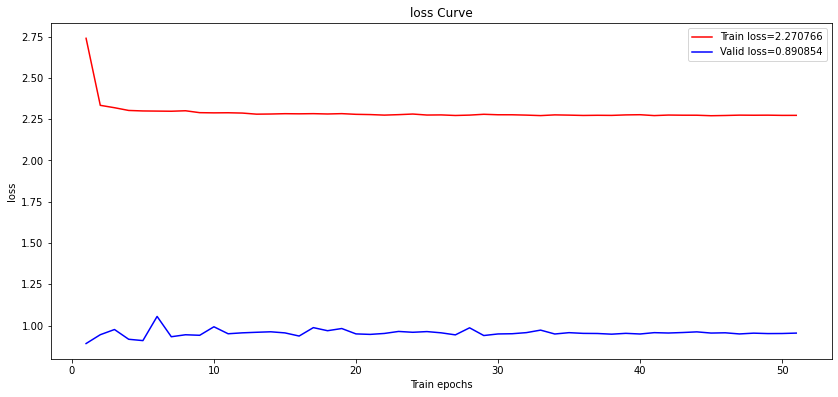

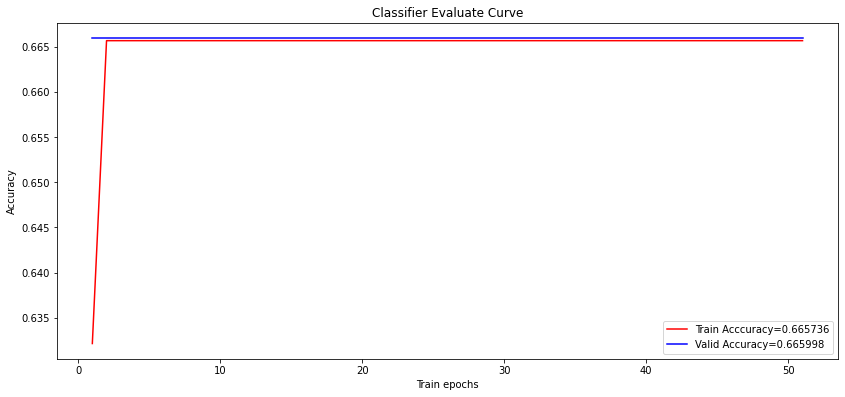

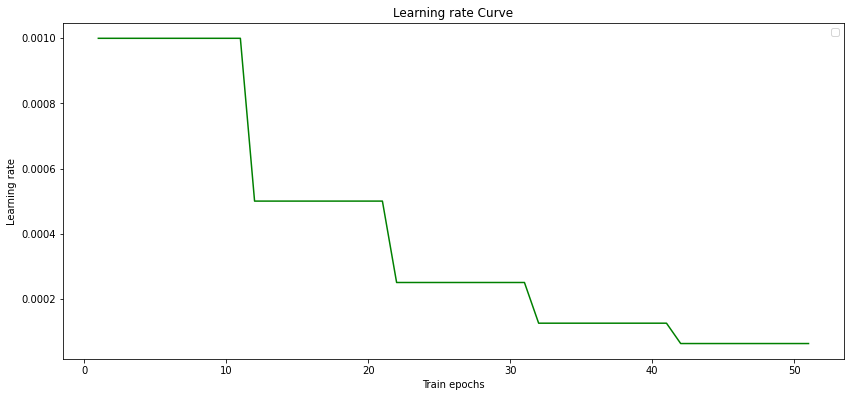

In [49]:
DisplayCurve(history=History,epoch=Epoch)

In [50]:
#计算训练集Accuracy
CerebriScan_VIT.evaluate(ImageDataset_Train,return_dict=True)

2025-09-12 19:21:15.659384: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 4655
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

187/187 [==============================] - 92s 476ms/step - loss: 0.8905 - accuracy: 0.6657


{'loss': 0.8905112743377686, 'accuracy': 0.6657357811927795}

In [51]:
#评估验证集Accuracy
CerebriScan_VIT.evaluate(ImageDataset_Valid,return_dict=True)

2025-09-12 19:22:55.808902: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 997
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\024TensorSliceDataset:6"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        t

40/40 [==============================] - 21s 482ms/step - loss: 0.8900 - accuracy: 0.6660


{'loss': 0.8900498151779175, 'accuracy': 0.6659979820251465}

In [52]:
#计算测试集Accuracy
CerebriScan_VIT.evaluate(ImageDataset_Test,return_dict=True)

2025-09-12 19:23:18.730885: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:776] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorSliceDataset/_2"
op: "TensorSliceDataset"
input: "Placeholder/_0"
input: "Placeholder/_1"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_STRING
      type: DT_INT64
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 998
  }
}
attr {
  key: "is_files"
  value {
    b: false
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\025TensorSliceDataset:12"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_STRING
        }
      }
      args {
        

40/40 [==============================] - 20s 480ms/step - loss: 0.8913 - accuracy: 0.6653


{'loss': 0.8913174271583557, 'accuracy': 0.6653306484222412}

评估precision,recall,f1_score,accuracy和混淆举证

In [ ]:
def PredictComputeGPU(Model, Dataset):
    # 存储所有批次结果的列表（使用tf.Tensor避免Python对象内存膨胀）
    true_labels = []
    pred_labels = []
    # 遍历数据集批次（已通过batch处理，避免单样本操作）
    for data_batch, label_batch in Dataset:
        # 关键优化：使用模型直接调用替代predict，避免额外内存开销
        # training=False确保推理模式（关闭dropout等）
        with tf.device('/GPU:0'):  # 显式指定GPU加速（如无GPU可移除）
            predict_proba = Model(data_batch, training=False) 
        # 直接在TensorFlow图中计算预测标签（避免numpy转换开销）
        # 等价于原代码的np.argmax + index_proba映射（因index_proba是[0,1,2]可简化）
        predict_label_batch = tf.argmax(predict_proba, axis=1, output_type=tf.int32)  
        # 转换为numpy并存储（批量操作而非单样本）
        true_labels.append(label_batch.numpy())
        pred_labels.append(predict_label_batch.numpy())
    # 合并所有批次结果（一次性操作比逐个append更高效）
    Label = np.concatenate(true_labels, axis=0)
    PredictLabel = np.concatenate(pred_labels, axis=0)
    
    return Label, PredictLabel

In [53]:
#使用评估函数评估模型性能
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
def ValidClass(Label,PredictLabel):
    TestPrecision=precision_score(Label,PredictLabel,average='micro')
    TestRecall=recall_score(Label,PredictLabel,average='micro')
    TestF1=f1_score(Label,PredictLabel,average='micro')
    TestAccuracy=accuracy_score(Label,PredictLabel)
    print('模型测试集Precision:{0},Recall:{1},F1_score:{2},Accuracy:{3}'.format(TestPrecision,TestRecall,TestF1,TestAccuracy))
    print('-------------------数据集混淆举证-------------------')
    ConfusionMatrix_result=confusion_matrix(Label,PredictLabel,labels=[0,1,2])    #计算混淆举证
    Display_ConfusionMatrix=ConfusionMatrixDisplay(ConfusionMatrix_result,display_labels=['Normal','Ischemia','Bleeding'])
    Display_ConfusionMatrix.plot(include_values=True, cmap='viridis', xticks_rotation='horizontal', values_format='d', ax=None)
    plt.title('Confusion Matrix')
    plt.show()

In [54]:
from sklearn.metrics import classification_report
from scipy.stats import chi2_contingency
from pandas import DataFrame
def Chi2_Test(Label,PredictLabel):
    print('-------------------数据集分类报告-------------------')
    print(classification_report(Label,PredictLabel,target_names=['Normal','Ischemia','Bleeding']))
    contingency_table = pd.crosstab(Label,PredictLabel, rownames=['True Label'], colnames=['Predict Label'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print('-------------------预测标签与真实标签卡方检验结果-------------------')
    print('卡方值为:{0},p值为:{1},自由度为:{2}'.format(chi2,p_value,dof))
    print('-------------------列联表-------------------')
    return DataFrame(contingency_table)

训练集评估

In [55]:
TrainLabel,TrainPredict=PredictComputeGPU(Model=CerebriScan_VIT,Dataset=ImageDataset_Train)

模型测试集Precision:0.6657357679914071,Recall:0.6657357679914071,F1_score:0.6657357679914071,Accuracy:0.6657357679914071
-------------------数据集混淆举证-------------------


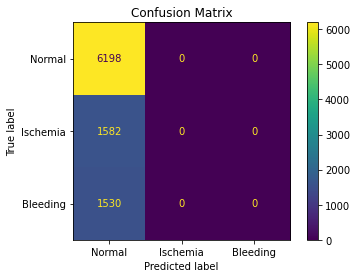

In [56]:
ValidClass(Label=TrainLabel,PredictLabel=TrainPredict)

In [57]:
Train_PE=Chi2_Test(Label=TrainLabel,PredictLabel=TrainPredict)

-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.67      1.00      0.80      6198
    Ischemia       0.00      0.00      0.00      1582
    Bleeding       0.00      0.00      0.00      1530

    accuracy                           0.67      9310
   macro avg       0.22      0.33      0.27      9310
weighted avg       0.44      0.67      0.53      9310

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:0.0,p值为:1.0,自由度为:0
-------------------列联表-------------------


/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [58]:
Train_PE

Predict Label,0
True Label,
0,6198
1,1582
2,1530


验证集评估

In [59]:
ValidLabel,ValidPredict=PredictComputeGPU(Model=CerebriScan_VIT,Dataset=ImageDataset_Valid)

模型测试集Precision:0.6659979939819458,Recall:0.6659979939819458,F1_score:0.6659979939819458,Accuracy:0.6659979939819458
-------------------数据集混淆举证-------------------


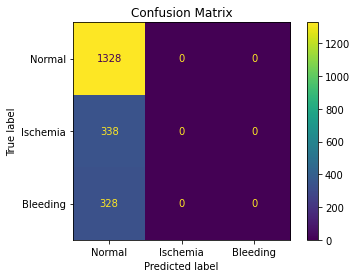

In [60]:
ValidClass(Label=ValidLabel,PredictLabel=ValidPredict)

In [61]:
Valid_PE=Chi2_Test(Label=ValidLabel,PredictLabel=ValidPredict)

-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.67      1.00      0.80      1328
    Ischemia       0.00      0.00      0.00       338
    Bleeding       0.00      0.00      0.00       328

    accuracy                           0.67      1994
   macro avg       0.22      0.33      0.27      1994
weighted avg       0.44      0.67      0.53      1994

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:0.0,p值为:1.0,自由度为:0
-------------------列联表-------------------


/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [62]:
Valid_PE

Predict Label,0
True Label,
0,1328
1,338
2,328


测试集评估

In [63]:
TestLabel,TestPredict=PredictComputeGPU(Model=CerebriScan_VIT,Dataset=ImageDataset_Test)

模型测试集Precision:0.6653306613226453,Recall:0.6653306613226453,F1_score:0.6653306613226453,Accuracy:0.6653306613226453
-------------------数据集混淆举证-------------------


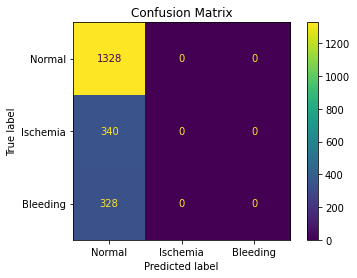

In [64]:
ValidClass(Label=TestLabel,PredictLabel=TestPredict)

In [65]:
Test_PE=Chi2_Test(Label=TestLabel,PredictLabel=TestPredict)

-------------------数据集分类报告-------------------
              precision    recall  f1-score   support

      Normal       0.67      1.00      0.80      1328
    Ischemia       0.00      0.00      0.00       340
    Bleeding       0.00      0.00      0.00       328

    accuracy                           0.67      1996
   macro avg       0.22      0.33      0.27      1996
weighted avg       0.44      0.67      0.53      1996

-------------------预测标签与真实标签卡方检验结果-------------------
卡方值为:0.0,p值为:1.0,自由度为:0
-------------------列联表-------------------


/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/miniconda3/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [66]:
Test_PE

Predict Label,0
True Label,
0,1328
1,340
2,328
